In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

# Add the project root to the path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.qnn_classifier import QNNClassifier, load_and_preprocess_data

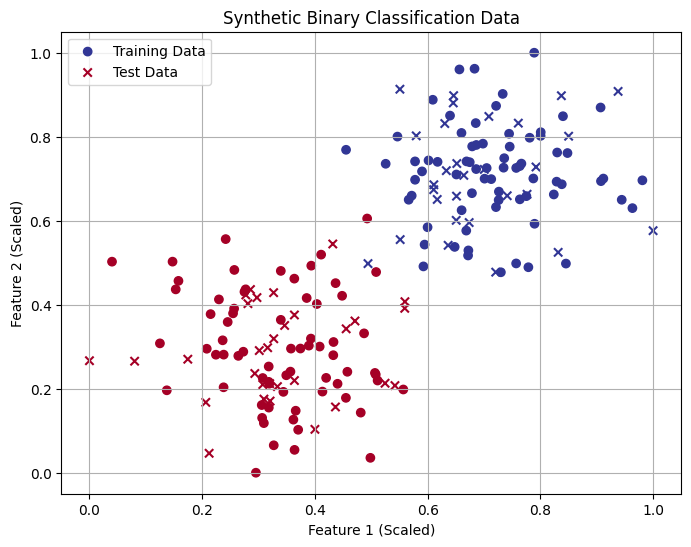

In [2]:
NUM_SAMPLES = 200
X_train, X_test, y_train, y_test = load_and_preprocess_data(NUM_SAMPLES)

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdYlBu, marker='o', label='Training Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.RdYlBu, marker='x', label='Test Data')
plt.title("Synthetic Binary Classification Data")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
NUM_QUBITS = 2
FEATURE_DIM = 2

classifier = QNNClassifier(num_qubits=NUM_QUBITS, feature_dim=FEATURE_DIM)
classifier.train(X_train, y_train)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30112\2171675686.py:5: DeprecationWarning: Sampler has been deprecated as of Aer 0.15, please use SamplerV2 instead.
  classifier.train(X_train, y_train)


Starting VQC training...
Training complete.


Test Accuracy: 91.67%


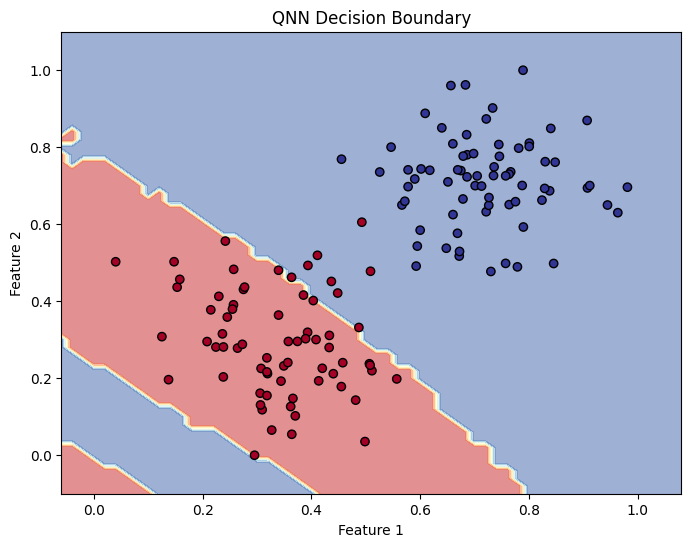

In [4]:
# --- Cell 4: Evaluate and Visualize Decision Boundary ---

accuracy = classifier.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2%}")

# Create a mesh grid of points to plot the decision boundary
h = .02  # step size in the mesh
x_min, x_max = X_train[:, 0].min() - .1, X_train[:, 0].max() + .1
y_min, y_max = X_train[:, 1].min() - .1, X_train[:, 1].max() + .1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Use the trained VQC to predict the class for each point in the grid
Z = classifier.vqc.predict(np.c_[xx.ravel(), yy.ravel()])

# Reshape the predictions to match the grid shape
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.5)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.RdYlBu)
plt.title("QNN Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()